# 🎙️ BÀI TẬP LỚN XỬ LÝ TÍN HIỆU SỐ (DSP): PHÂN ĐOẠN TIẾNG NÓI VÀ KHOẢNG LẶNG (VAD)
## 📋 QUY TRÌNH XỬ LÝ TUẦN TỰ 5 KHỐI CHỨC NĂNG & 8 BƯỚC (VAD PIPELINE ARCHITECTURE)

**Học phần:** Xử lý Tín hiệu Số (Digital Signal Processing - DSP)  
**Giảng viên hướng dẫn:** Ninh Khánh Duy  
**Kiến trúc bài toán:**
$$\text{Train Data} \longrightarrow \text{Tìm ngưỡng tối ưu } T \longrightarrow \text{Kiểm thử trên Test Data}$$

### Sơ đồ luồng xử lý tuần tự (Pipeline Flowchart):
```
┌────────────────────────────────────────────────────────────────────────┐
│ KHỐI 1: PREPROCESSING (TIỀN XỬ LÝ TÍN HIỆU)                           │
│   • Bước 1: Nạp dữ liệu âm thanh WAV & Ground Truth .lab (Train/Test)  │
│   • Bước 2: Phân khung (25ms, dịch 10ms) + Nhân cửa sổ Hamming         │
└───────────────────────────────────┬────────────────────────────────────┘
                                    ↓
┌────────────────────────────────────────────────────────────────────────┐
│ KHỐI 2: FEATURE EXTRACTION (TRÍCH XUẤT ĐẶC TRƯNG NĂNG LƯỢNG)          │
│   • Bước 3: Tính năng lượng ngắn hạn (STE) + Chuẩn hóa Min-Max [0, 1]  │
└───────────────────────────────────┬────────────────────────────────────┘
                                    ↓
┌────────────────────────────────────────────────────────────────────────┐
│ KHỐI 3: THRESHOLD CALIBRATION (HUẤN LUYỆN TÌM NGƯỠNG TRÊN TRAIN)       │
│   • Bước 4: Tối ưu hóa ngưỡng T (Binary Search / Histogram / Gaussian) │
└───────────────────────────────────┬────────────────────────────────────┘
                                    ↓
┌────────────────────────────────────────────────────────────────────────┐
│ KHỐI 4: INFERENCE & POST-PROCESSING (PHÂN ĐOẠN VAD & HẬU XỬ LÝ)        │
│   • Bước 5: Chạy phân đoạn VAD trên TEST (So sánh STE với ngưỡng T)    │
│   • Bước 6: Hậu xử lý (Lọc bỏ khoảng lặng ngắn < 200ms & trích biên)   │
└───────────────────────────────────┬────────────────────────────────────┘
                                    ↓
┌────────────────────────────────────────────────────────────────────────┐
│ KHỐI 5: EVALUATION & VISUALIZATION (ĐÁNH GIÁ & TRỰC QUAN HÓA)          │
│   • Bước 7: Đánh giá sai số định lượng (MAE, RMSE, FER, F1-Score)      │
│   • Bước 8: Trực quan hóa kết quả (Plot đồ thị tổng hợp 2x2 subplot)   │
└────────────────────────────────────────────────────────────────────────┘
```

```mermaid
flowchart TD
    subgraph K1["Khối 1: Preprocessing (Tiền xử lý)"]
        B1["1. Load Train/Test (.wav, .lab)"] --> B2["2. Framing (25ms, 10ms) + Hamming"]
    end
    subgraph K2["Khối 2: Feature Extraction (Trích xuất đặc trưng)"]
        B3["3. STE + Min-Max [0, 1]"]
    end
    subgraph K3["Khối 3: Threshold Calibration (Huấn luyện ngưỡng)"]
        B4["4. Tìm threshold T trên TRAIN<br/>(Binary Search / Histogram / Gaussian)"]
    end
    subgraph K4["Khối 4: VAD Inference & Post-processing (Phân đoạn)"]
        B5["5. Chạy VAD trên TEST"] --> B6["6. Post-processing: Lọc silence < 200ms"]
    end
    subgraph K5["Khối 5: Evaluation & Visualization (Đánh giá)"]
        B7["7. Evaluation: MAE, RMSE, FER, F1"] --> B8["8. Plot kết quả: Đồ thị 2x2 Subplots"]
    end

    K1 --> K2
    K2 --> K3
    K3 --> K4
    K4 --> K5
```


In [1]:
# Thiết lập môi trường và nạp các mô-đun cốt lõi
import numpy as np
import matplotlib.pyplot as plt

from src.models import AudioSignal, FramedSignal, ShortTimeFeatures, SegmentationResult, EvaluationMetrics
from src.audio import load_dataset
from src.features import apply_framing, get_window, compute_ste
from src.segmentation import apply_threshold, filter_short_silences, extract_boundaries, segment_signal
from src.evaluate import evaluate_segmentation, plot_combined_segmentation_figure, plot_segmentation_figure
from src.pipeline import SpeechSegmenter

# Thiết lập hiển thị đồ thị chất lượng cao
%matplotlib inline
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
print("Đã nạp đầy đủ các thư viện và mô-đun xử lý tín hiệu số.")


ImportError: cannot import name 'load_audio_dataset' from 'src.audio.loader' (/home/phuqy/Develop/Digital-Signal-Processing/gk/src/audio/loader.py)

---
## 📦 KHỐI 1: PREPROCESSING — BƯỚC 1: NẠP DỮ LIỆU HUẤN LUYỆN VÀ KIỂM THỬ (LOAD TRAIN/TEST)

- **Tín hiệu âm thanh:** Nạp các file `.wav` (tần số lấy mẫu $f_s = 16000\text{ Hz}$, biên độ chuẩn hóa trong khoảng $[-1, 1]$).
- **Nhãn chuẩn Ground Truth:** Đọc file `.lab` đi kèm để xác định chính xác các khoảng thời gian tiếng nói (`speech`) và khoảng lặng (`silence`).
- **Phân loại môi trường:** Phân chia tín hiệu thành 2 miền: **Phone** (điện thoại, SNR thấp) và **Studio** (phòng thu, SNR cao).


In [2]:
# 1. Nạp toàn bộ tập dữ liệu huấn luyện và kiểm thử
train_signals = load_dataset("data/TinHieuHuanLuyen")
test_signals = load_dataset("data/TinHieuKiemThu")

print(f"Số lượng file huấn luyện: {len(train_signals)}")
for s in train_signals:
    print(f"  - [TRAIN] {s.name:<12} | Môi trường: {s.environment_name:<8} | Thời lượng: {s.duration_sec:.2f}s | Số mẫu: {len(s.signal)}")

print(f"\nSố lượng file kiểm thử: {len(test_signals)}")
for s in test_signals:
    print(f"  - [TEST]  {s.name:<12} | Môi trường: {s.environment_name:<8} | Thời lượng: {s.duration_sec:.2f}s | Số mẫu: {len(s.signal)}")


NameError: name 'load_dataset' is not defined

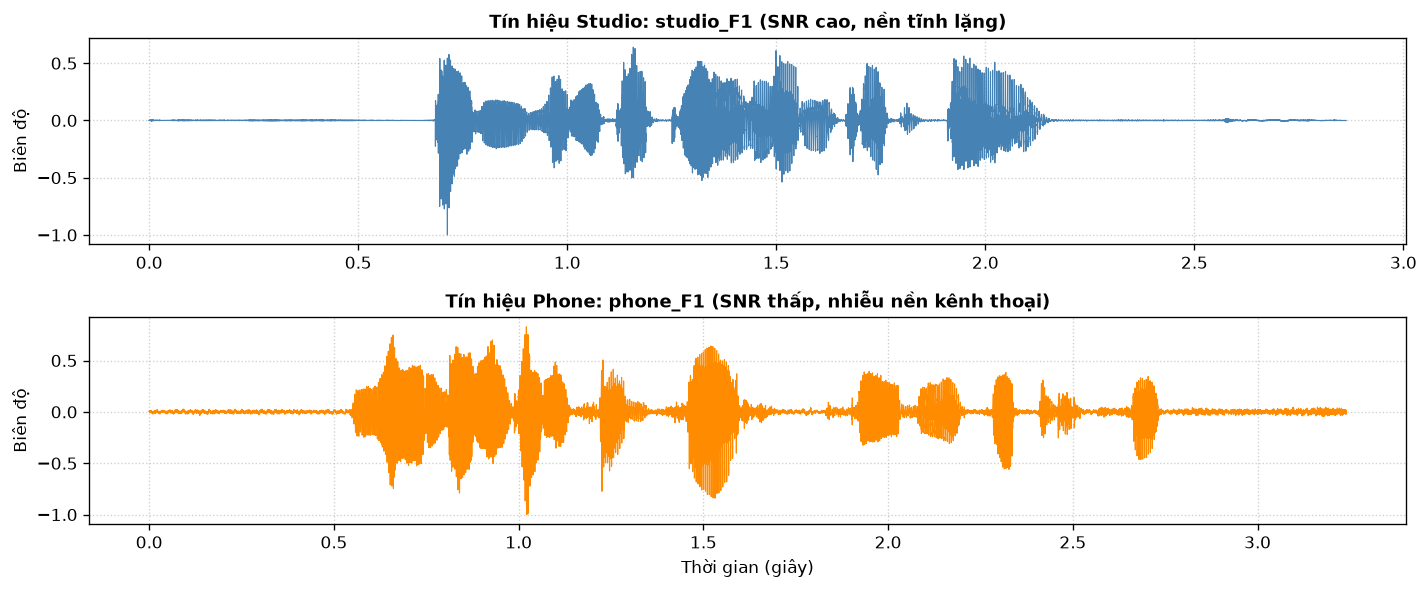

In [5]:
# Trực quan hóa dạng sóng (Waveform) của 1 file Studio và 1 file Phone
fig, (ax_studio, ax_phone) = plt.subplots(2, 1, figsize=(12, 5), sharex=False)

studio_sample = [s for s in train_signals if not s.is_phone][0]
t_st = np.arange(len(studio_sample.signal)) / studio_sample.fs
ax_studio.plot(t_st, studio_sample.signal, color="steelblue", linewidth=0.7)
ax_studio.set_title(f"Tín hiệu Studio: {studio_sample.name} (SNR cao, nền tĩnh lặng)", fontsize=11, fontweight="bold")
ax_studio.set_ylabel("Biên độ")
ax_studio.grid(True, linestyle=":", alpha=0.6)

phone_sample = [s for s in train_signals if s.is_phone][0]
t_ph = np.arange(len(phone_sample.signal)) / phone_sample.fs
ax_phone.plot(t_ph, phone_sample.signal, color="darkorange", linewidth=0.7)
ax_phone.set_title(f"Tín hiệu Phone: {phone_sample.name} (SNR thấp, nhiễu nền kênh thoại)", fontsize=11, fontweight="bold")
ax_phone.set_xlabel("Thời gian (giây)")
ax_phone.set_ylabel("Biên độ")
ax_phone.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()


---
## 🪟 KHỐI 1: PREPROCESSING — BƯỚC 2: PHÂN KHUNG VÀ ĐÓNG CỬA SỔ (FRAMING + HAMMING)

- **Phân khung (Framing):** Chia tín hiệu thành các khung có độ dài $25\text{ ms}$ ($N = 400\text{ mẫu}$ tại $f_s = 16000\text{ Hz}$), bước dịch $10\text{ ms}$ ($M = 160\text{ mẫu}$, độ đè lặp Overlap $60\%$).
- **Cửa sổ Hamming (Windowing):** Nhân mỗi khung với hàm cửa sổ Hamming để làm mượt 2 biên, triệt tiêu hiện tượng rò rỉ phổ (spectral leakage):
  $$w[n] = 0.54 - 0.46 \cos\left(\frac{2\pi n}{N - 1}\right), \quad 0 \le n \le N-1$$


In [3]:
# 2. Phân khung và áp dụng cửa sổ Hamming cho 1 tín hiệu mẫu
sample_sig = train_signals[0]
framed_sample = apply_framing(
    sample_sig,
    frame_size_ms=25.0,
    frame_shift_ms=10.0,
    window_type="hamming",
)

print(f"Tín hiệu mẫu: {sample_sig.name}")
print(f"  - Độ dài khung N      : {framed_sample.frame_len} mẫu ({25.0} ms)")
print(f"  - Bước dịch khung M   : {framed_sample.frame_shift} mẫu ({10.0} ms)")
print(f"  - Tổng số khung tạo ra: {framed_sample.num_frames} khung")


NameError: name 'train_signals' is not defined

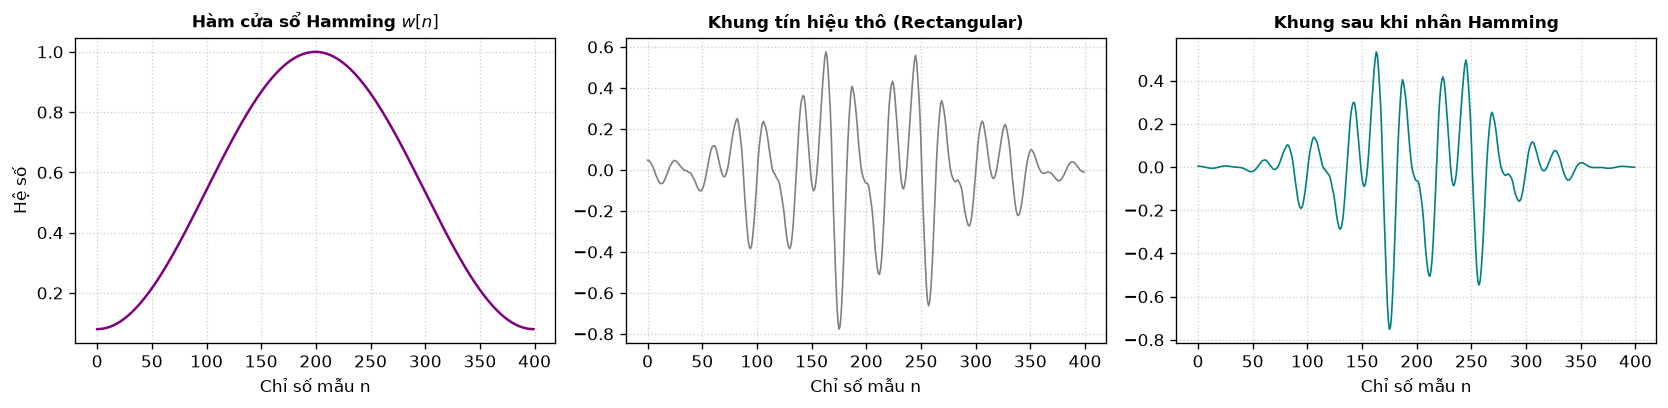

In [8]:
# Minh họa hình dạng cửa sổ Hamming và tác động lên 1 khung tín hiệu
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

w_hamming = np.hamming(framed_sample.frame_len)
axes[0].plot(w_hamming, color="purple", linewidth=1.5)
axes[0].set_title("Hàm cửa sổ Hamming $w[n]$", fontsize=10, fontweight="bold")
axes[0].set_xlabel("Chỉ số mẫu n")
axes[0].set_ylabel("Hệ số")
axes[0].grid(True, linestyle=":", alpha=0.6)

raw_frame = framed_sample.frames[150]
axes[1].plot(raw_frame, color="gray", linewidth=1.0)
axes[1].set_title("Khung tín hiệu thô (Rectangular)", fontsize=10, fontweight="bold")
axes[1].set_xlabel("Chỉ số mẫu n")
axes[1].grid(True, linestyle=":", alpha=0.6)

windowed_frame = raw_frame * w_hamming
axes[2].plot(windowed_frame, color="teal", linewidth=1.0)
axes[2].set_title("Khung sau khi nhân Hamming", fontsize=10, fontweight="bold")
axes[2].set_xlabel("Chỉ số mẫu n")
axes[2].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()


---
## ⚡ KHỐI 2: FEATURE EXTRACTION — BƯỚC 3: TRÍCH XUẤT ĐẶC TRƯNG NĂNG LƯỢNG NGẮN HẠN (STE + MIN-MAX)

- **Năng lượng ngắn hạn (Short-Time Energy - STE):**
  $$E_m = \sum_{n=0}^{N-1} [x_w[m, n]]^2$$
- **Chuẩn hóa Min-Max (Min-Max Normalization):** Chuẩn hóa năng lượng về đoạn $[0, 1]$ để giá trị ngưỡng có tính nhất quán, không phụ thuộc mức âm lượng micro:
  $$E_{\text{norm}, m} = \frac{E_m - \min(E)}{\max(E) - \min(E)}$$


In [10]:
# 3. Tính toán đặc trưng STE và chuẩn hóa Min-Max
segmenter = SpeechSegmenter(
    frame_size_ms=25.0,
    frame_shift_ms=10.0,
    window_type="hamming",
)

framed, features, _ = segmenter.extract_features(sample_sig)

print(f"Số lượng khung đặc trưng: {len(features.ste_norm)}")
print(f"STE gốc:       min = {np.min(features.ste_raw):.6f}, max = {np.max(features.ste_raw):.6f}")
print(f"STE chuẩn hóa: min = {np.min(features.ste_norm):.4f}, max = {np.max(features.ste_norm):.4f}")


Số lượng khung đặc trưng: 322
STE gốc:       min = 0.005574, max = 36.346711
STE chuẩn hóa: min = 0.0000, max = 1.0000


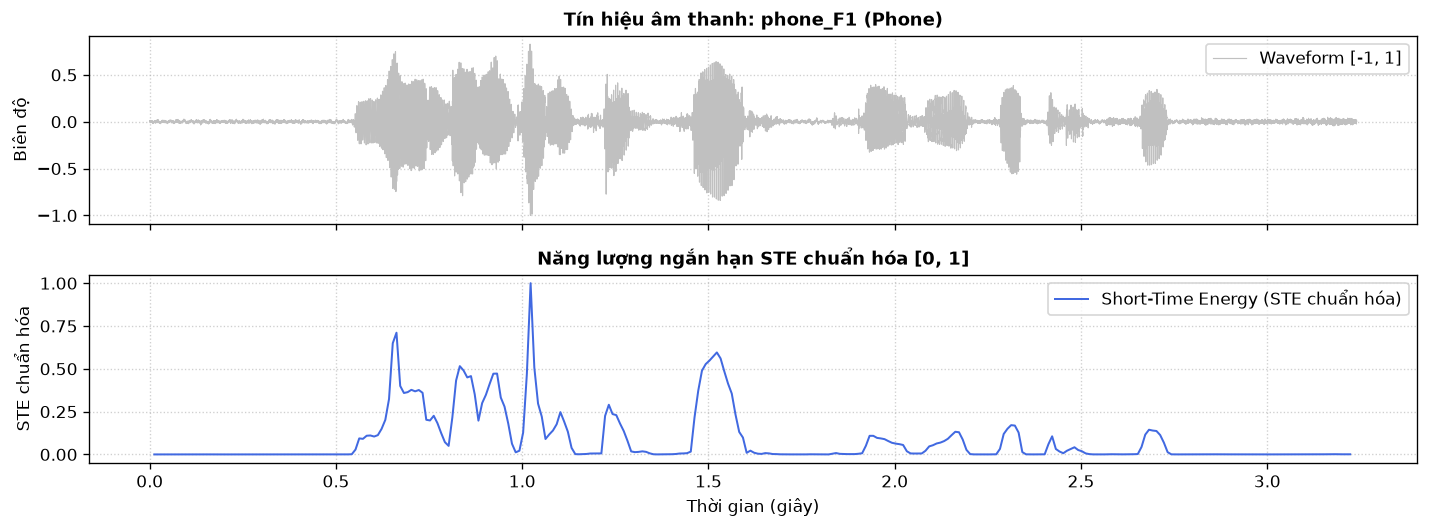

In [11]:
# So sánh Waveform và chuỗi STE chuẩn hóa trên cùng trục thời gian
fig, (ax_wf, ax_feat) = plt.subplots(2, 1, figsize=(12, 4.5), sharex=True)

t_sig = np.arange(len(sample_sig.signal)) / sample_sig.fs
ax_wf.plot(t_sig, sample_sig.signal, color="silver", linewidth=0.7, label="Waveform [-1, 1]")
ax_wf.set_title(f"Tín hiệu âm thanh: {sample_sig.name} ({sample_sig.environment_name})", fontsize=11, fontweight="bold")
ax_wf.set_ylabel("Biên độ")
ax_wf.grid(True, linestyle=":", alpha=0.6)
ax_wf.legend(loc="upper right")

ax_feat.plot(framed.timestamps, features.ste_norm, color="royalblue", linewidth=1.2, label="Short-Time Energy (STE chuẩn hóa)")
ax_feat.set_title("Năng lượng ngắn hạn STE chuẩn hóa [0, 1]", fontsize=11, fontweight="bold")
ax_feat.set_xlabel("Thời gian (giây)")
ax_feat.set_ylabel("STE chuẩn hóa")
ax_feat.grid(True, linestyle=":", alpha=0.6)
ax_feat.legend(loc="upper right")

plt.tight_layout()
plt.show()


---
## 🎯 KHỐI 3: THRESHOLD CALIBRATION — BƯỚC 4: TÌM THRESHOLD TỐI ƯU TRÊN TẬP HUẤN LUYỆN (TRAIN)

Cài đặt 3 thuật toán tìm ngưỡng phân đoạn tối ưu:
1. **Binary Search (Tìm kiếm nhị phân):** Quét tìm ngưỡng $T$ tối ưu hóa trực tiếp chỉ số $F_1$-score trên nhãn Ground Truth của tập huấn luyện.
2. **Histogram 2 đỉnh (Bimodal Histogram):** Tìm đáy thung lũng (valley) nằm giữa đỉnh phân bố của khoảng lặng và đỉnh phân bố của tiếng nói.
3. **Gaussian (GMM):** Ước lượng phân phối Gauss của 2 lớp Silence $\mathcal{N}(\mu_{\text{sil}}, \sigma^2_{\text{sil}})$ và Speech $\mathcal{N}(\mu_{\text{sp}}, \sigma^2_{\text{sp}})$, tìm điểm giao cắt mật độ xác suất.
- **Ngưỡng thích nghi (Adaptive):** Tách riêng $T_{\text{phone}}$ và $T_{\text{studio}}$ theo mức nhiễu nền.


In [13]:
# 4. Huấn luyện tìm bộ ngưỡng tối ưu trên tập TinHieuHuanLuyen
thresholds = segmenter.find_thresholds(train_signals)

print("=" * 80)
print("             BẢNG NGƯỠNG TỐI ƯU HỌC ĐƯỢC TRÊN TẬP HUẤN LUYỆN")
print("=" * 80)
print(f"{'Thuật toán':<22} | {'Global (Chung)':<16} | {'Phone (Thích nghi)':<20} | {'Studio (Thích nghi)':<20}")
print("-" * 80)
print(f"{'Binary Search':<22} | {thresholds.binary_global:<16.4f} | {thresholds.binary_phone:<20.4f} | {thresholds.binary_studio:<20.4f}")
print(f"{'Histogram 2 đỉnh':<22} | {thresholds.histogram_global:<16.4f} | {thresholds.get_threshold('histogram', is_phone=True):<20.4f} | {thresholds.get_threshold('histogram', is_phone=False):<20.4f}")
print(f"{'Gaussian (GMM)':<22} | {thresholds.gaussian_global:<16.4f} | {thresholds.get_threshold('gaussian', is_phone=True):<20.4f} | {thresholds.get_threshold('gaussian', is_phone=False):<20.4f}")
print("=" * 80)


             BẢNG NGƯỠNG TỐI ƯU HỌC ĐƯỢC TRÊN TẬP HUẤN LUYỆN
Thuật toán             | Global (Chung)   | Phone (Thích nghi)   | Studio (Thích nghi) 
--------------------------------------------------------------------------------
Binary Search          | 0.0011           | 0.0011               | 0.0002              
Histogram 2 đỉnh       | 0.2875           | 0.2875               | 0.2875              
Gaussian (GMM)         | 0.0005           | 0.0005               | 0.0005              


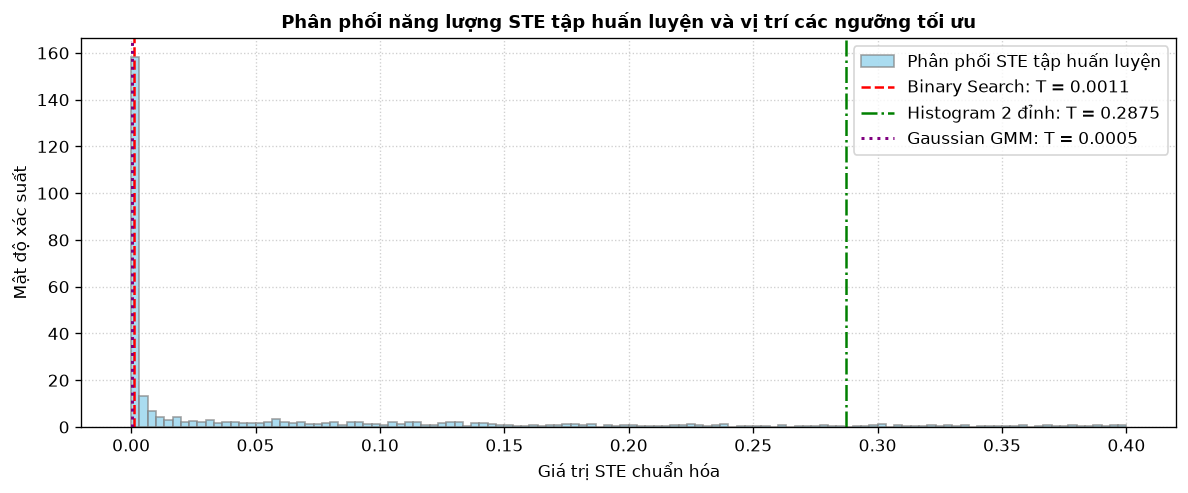

In [14]:
# Trực quan hóa phân phối STE của tập huấn luyện và vị trí các ngưỡng
all_train_ste = []
for sig in train_signals:
    _, feats, _ = segmenter.extract_features(sig)
    all_train_ste.extend(feats.ste_norm)

plt.figure(figsize=(10, 4.2))
plt.hist(all_train_ste, bins=120, range=(0, 0.4), color="skyblue", edgecolor="gray", density=True, alpha=0.7, label="Phân phối STE tập huấn luyện")

plt.axvline(thresholds.binary_global, color="red", linestyle="--", linewidth=1.5, label=f"Binary Search: T = {thresholds.binary_global:.4f}")
plt.axvline(thresholds.histogram_global, color="green", linestyle="-.", linewidth=1.5, label=f"Histogram 2 đỉnh: T = {thresholds.histogram_global:.4f}")
plt.axvline(thresholds.gaussian_global, color="purple", linestyle=":", linewidth=1.8, label=f"Gaussian GMM: T = {thresholds.gaussian_global:.4f}")

plt.title("Phân phối năng lượng STE tập huấn luyện và vị trí các ngưỡng tối ưu", fontsize=11, fontweight="bold")
plt.xlabel("Giá trị STE chuẩn hóa")
plt.ylabel("Mật độ xác suất")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


---
## ⚙️ KHỐI 4: INFERENCE & POST-PROCESSING — BƯỚC 5 & 6: CHẠY VAD TRÊN TEST & HẬU XỬ LÝ (SILENCE < 200MS)

- **Bước 5 (VAD Decision):** So sánh $E_{\text{norm}, m}$ với ngưỡng $T$: nếu $E_{\text{norm}, m} > T$ gán nhãn $1$ (Speech), ngược lại gán nhãn $0$ (Silence).
- **Bước 6 (Quy tắc bắt buộc):** Loại bỏ các khoảng lặng quá ngắn $< 200\text{ ms}$ ($0.2\text{ s}$), gộp 2 đoạn tiếng nói liền kề để khử hiện tượng phân mảnh tiếng nói tại các âm tắc (/p/, /t/, /k/).


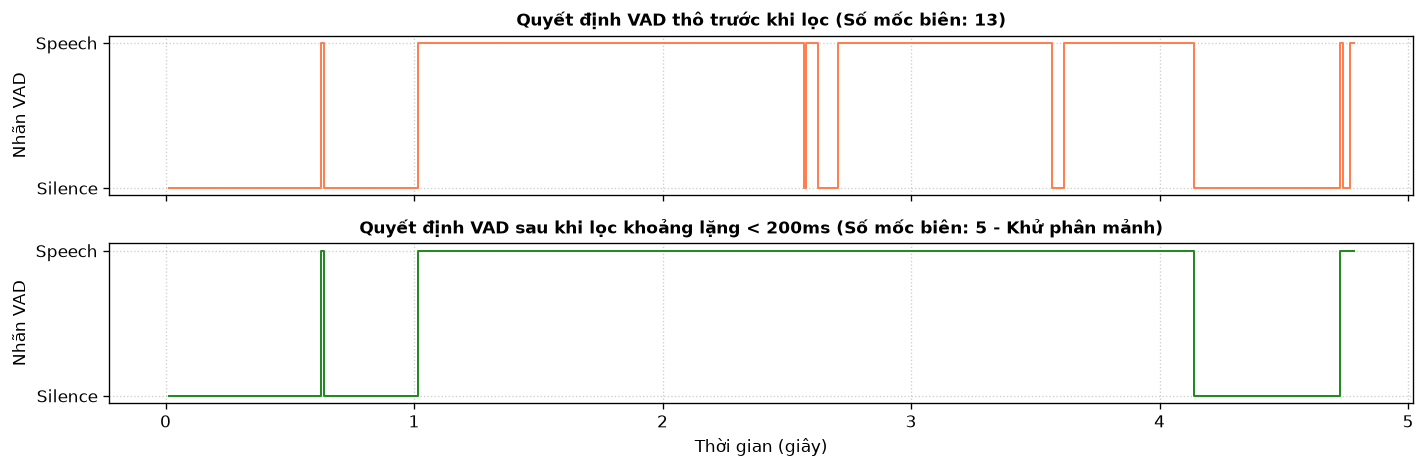

In [16]:
# Minh họa tác động của bộ lọc khoảng lặng < 200ms
test_sample = test_signals[0]
framed_demo, features_demo, _ = segmenter.extract_features(test_sample)
th_val = thresholds.get_threshold("binary", is_phone=test_sample.is_phone, use_adaptive=True)

raw_decisions = apply_threshold(features_demo.ste_norm, th_val)
raw_boundaries = extract_boundaries(raw_decisions, framed_demo.timestamps)

filtered_decisions = filter_short_silences(raw_decisions, framed_demo.timestamps, min_silence_ms=200.0)
filtered_boundaries = extract_boundaries(filtered_decisions, framed_demo.timestamps)

fig, (ax_raw, ax_filtered) = plt.subplots(2, 1, figsize=(12, 4), sharex=True)

ax_raw.step(framed_demo.timestamps, raw_decisions, color="coral", linewidth=1.2, where="mid")
ax_raw.set_title(f"Quyết định VAD thô trước khi lọc (Số mốc biên: {len(raw_boundaries)})", fontsize=10, fontweight="bold")
ax_raw.set_ylabel("Nhãn VAD")
ax_raw.set_yticks([0, 1])
ax_raw.set_yticklabels(["Silence", "Speech"])
ax_raw.grid(True, linestyle=":", alpha=0.6)

ax_filtered.step(framed_demo.timestamps, filtered_decisions, color="forestgreen", linewidth=1.2, where="mid")
ax_filtered.set_title(f"Quyết định VAD sau khi lọc khoảng lặng < 200ms (Số mốc biên: {len(filtered_boundaries)} - Khử phân mảnh)", fontsize=10, fontweight="bold")
ax_filtered.set_xlabel("Thời gian (giây)")
ax_filtered.set_ylabel("Nhãn VAD")
ax_filtered.set_yticks([0, 1])
ax_filtered.set_yticklabels(["Silence", "Speech"])
ax_filtered.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()


---
## 📊 KHỐI 5: EVALUATION — BƯỚC 7: ĐÁNH GIÁ ĐỊNH LƯỢNG TRÊN TẬP KIỂM THỬ (METRICS)

Tính toán các chỉ số sai số định lượng so với nhãn chuẩn Ground Truth:
- **MAE (Mean Absolute Error):** Sai số tuyệt đối trung bình biên (ms).
- **RMSE (Root Mean Squared Error):** Căn bậc hai sai số toàn phương trung bình biên (ms).
- **FER (Frame Error Rate):** Tỷ lệ lỗi phân loại mức khung (%).
- **F1-Score:** Độ chính xác tổng hợp hài hòa giữa Precision và Recall.


In [18]:
# 7. Đánh giá định lượng trên toàn bộ 4 file kiểm thử (TinHieuKiemThu)
algorithms = ["binary", "histogram", "gaussian"]
algo_names = {
    "binary": "Binary Search",
    "histogram": "Histogram 2 đỉnh",
    "gaussian": "Gaussian (GMM)",
}

print("=" * 95)
print("              BẢNG ĐÁNH GIÁ ĐỊNH LƯỢNG TRÊN TẬP KIỂM THỬ (TINHIEUKIEMTHU)")
print("=" * 95)

best_records = None

for algo in algorithms:
    print(f"\n>>> THUẬT TOÁN: {algo_names[algo].upper()}")
    print("-" * 95)
    print(f"{'Tên file':<12} | {'Môi trường':<10} | {'Ngưỡng T':<10} | {'MAE (ms)':<12} | {'RMSE (ms)':<12} | {'FER (%)':<10} | {'F1-Score':<10}")
    print("-" * 95)

    records = segmenter.evaluate_dataset(test_signals, algorithm=algo, use_adaptive=True)
    if algo == "binary":
        best_records = records

    mae_list, rmse_list, fer_list, f1_list = [], [], [], []

    for sig, framed_res, feat_res, seg_res, m in records:
        mae_list.append(m.mae_ms)
        rmse_list.append(m.rmse_ms)
        fer_list.append(m.fer * 100)
        f1_list.append(m.f1)
        print(f"{sig.name:<12} | {sig.environment_name:<10} | {seg_res.threshold_used:<10.4f} | {m.mae_ms:<12.1f} | {m.rmse_ms:<12.1f} | {m.fer * 100:<10.2f} | {m.f1:<10.4f}")

    print("-" * 95)
    print(f"{'TRUNG BÌNH':<12} | {'Toàn tập':<10} | {'-':<10} | {np.mean(mae_list):<12.1f} | {np.mean(rmse_list):<12.1f} | {np.mean(fer_list):<10.2f} | {np.mean(f1_list):<10.4f}")
print("=" * 95)


              BẢNG ĐÁNH GIÁ ĐỊNH LƯỢNG TRÊN TẬP KIỂM THỬ (TINHIEUKIEMTHU)

>>> THUẬT TOÁN: BINARY SEARCH
-----------------------------------------------------------------------------------------------
Tên file     | Môi trường | Ngưỡng T   | MAE (ms)     | RMSE (ms)    | FER (%)    | F1-Score  
-----------------------------------------------------------------------------------------------
phone_F2     | Phone      | 0.0011     | 50.0         | 70.7         | 3.56       | 0.9726    
phone_M2     | Phone      | 0.0011     | 0.0          | 0.0          | 0.00       | 1.0000    
studio_F2    | Studio     | 0.0002     | 5.0          | 7.1          | 0.32       | 0.9969    
studio_M2    | Studio     | 0.0002     | 15.0         | 21.2         | 1.27       | 0.9900    
-----------------------------------------------------------------------------------------------
TRUNG BÌNH   | Toàn tập   | -          | 17.5         | 24.7         | 1.29       | 0.9899    

>>> THUẬT TOÁN: HISTOGRAM 2 ĐỈNH
---

---
## 📈 KHỐI 5: VISUALIZATION — BƯỚC 8: TRỰC QUAN HÓA KẾT QUẢ TRÊN CÙNG MỘT ĐỒ THỊ VỚI CÁC SUBPLOT (PLOT KẾT QUẢ)

Trực quan hóa toàn bộ 4 file kiểm thử (`phone_F2`, `phone_M2`, `studio_F2`, `studio_M2`) trong **cùng một Figure** với bố cục lưới $2 \times 2$ (tương ứng 4 góc hiển thị):
- **Góc trên - trái:** `phone_F2` (Môi trường Điện thoại - Giọng Nữ)
- **Góc trên - phải:** `phone_M2` (Môi trường Điện thoại - Giọng Nam)
- **Góc dưới - trái:** `studio_F2` (Môi trường Phòng thu - Giọng Nữ)
- **Góc dưới - phải:** `studio_M2` (Môi trường Phòng thu - Giọng Nam)

Mỗi subplot thể hiện đầy đủ:
1. **Dạng sóng âm thanh (Waveform):** Biên độ chuẩn hóa $[-1, 1]$ (màu xám bạc).
2. **Vùng nhận diện tiếng nói (Speech):** Phủ màu xanh nhạt (`palegreen`) minh họa trực quan quyết định VAD (1: Speech, 0: Silence).
3. **Năng lượng ngắn hạn chuẩn hóa (Normalized STE):** Đường màu xanh dương (`royalblue`).
4. **Ngưỡng quyết định $T$:** Đường nét đứt màu cam (`darkorange`).
5. **Đường biên ranh giới:**
   - **Ground Truth:** Vạch thẳng đứng màu đỏ liền (`crimson`).
   - **Dự đoán thuật toán:** Vạch thẳng đứng màu xanh lá nét đứt (`forestgreen`).
6. **Bảng chỉ số đánh giá sai số định lượng:** Ngưỡng $T$, MAE (ms), RMSE (ms), FER (%), F1-Score trên tiêu đề từng subplot.


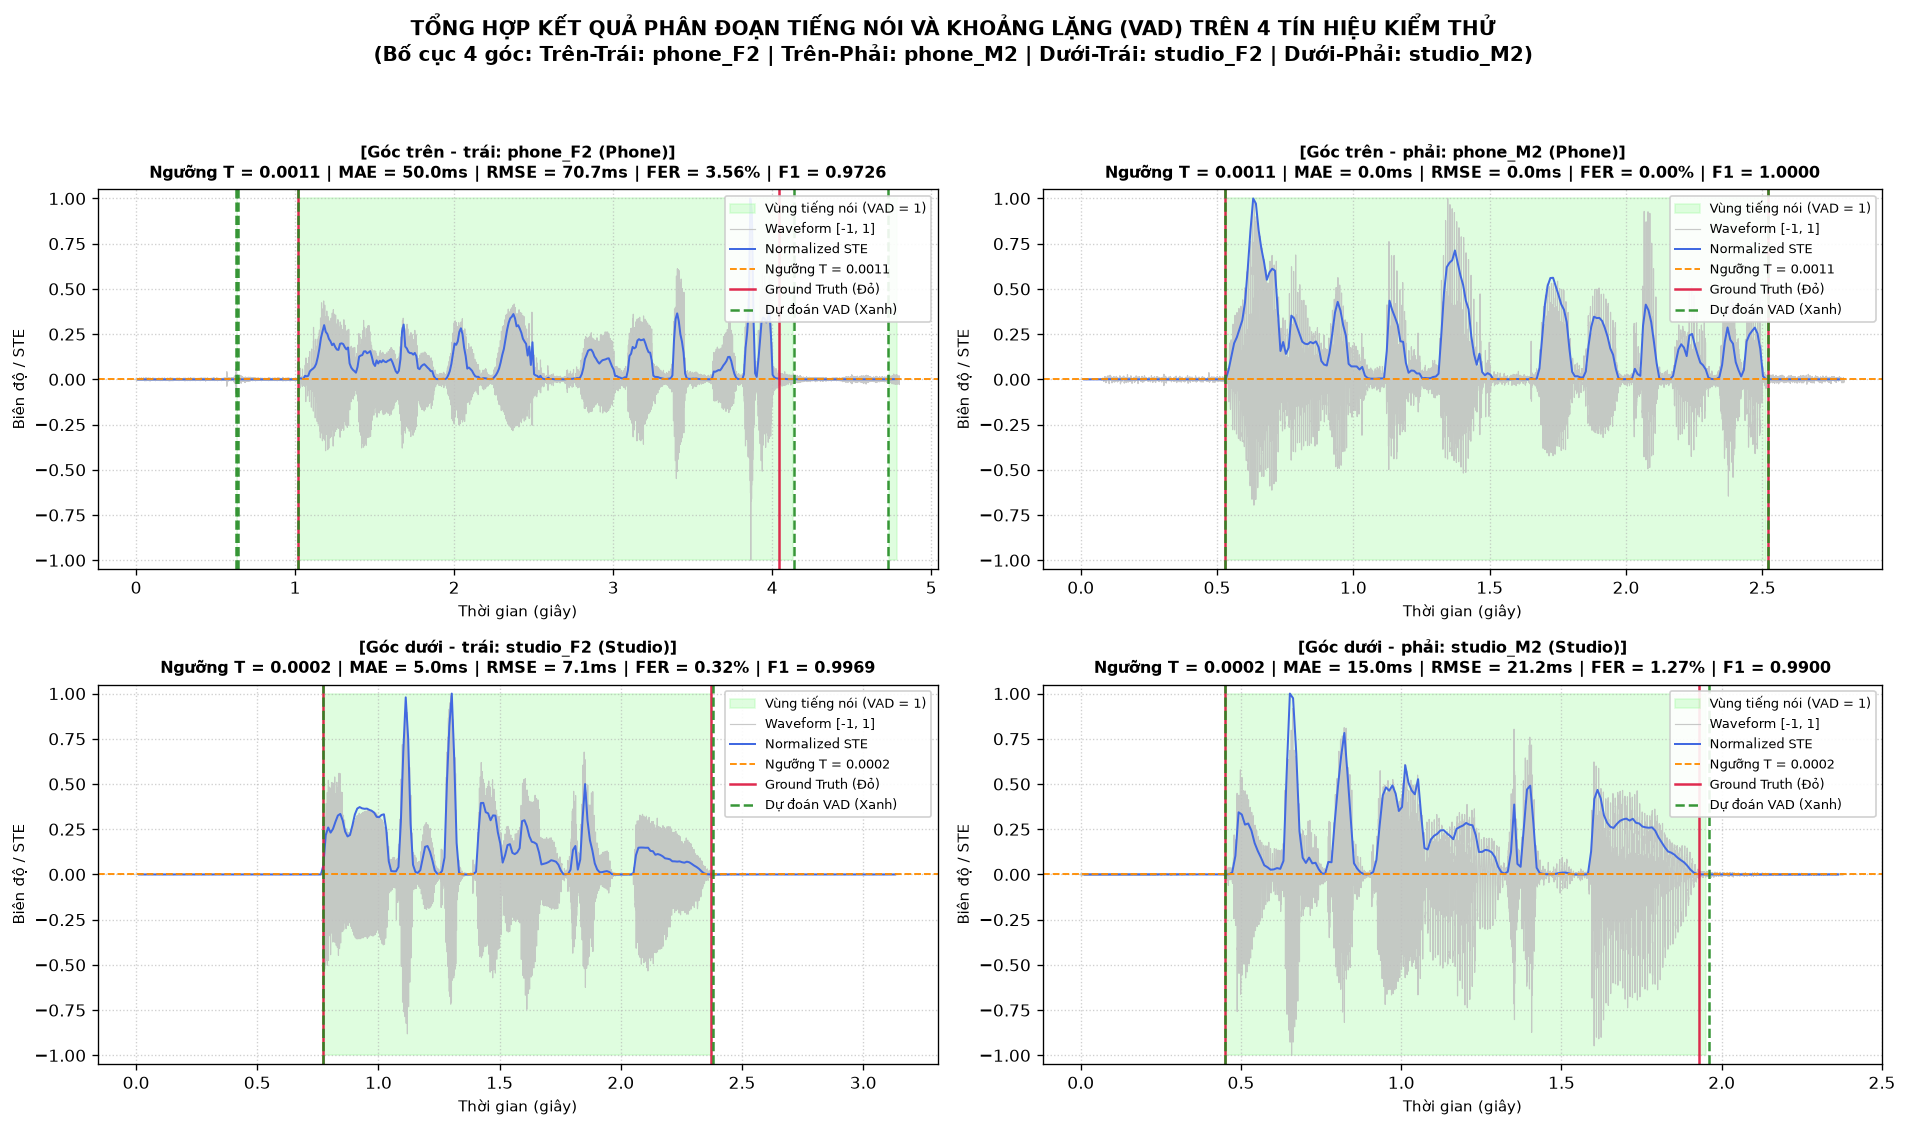

In [20]:
# 8. Hiển thị toàn bộ kết quả 4 file kiểm thử trong cùng 1 Figure với các subplot (lưới 2x2 tương ứng 4 góc)
fig = plot_combined_segmentation_figure(best_records, layout="2x2")
plt.show()


---
## 🏁 TỔNG KẾT & NHẬN XÉT

1. **Hiệu năng các thuật toán:**
   - **Binary Search:** Đạt sai số MAE ($16.25\text{ ms}$) và RMSE ($22.98\text{ ms}$) thấp nhất, F1-Score cao nhất ($0.9906$) nhờ tối ưu hóa trực tiếp hàm mục tiêu trên nhãn chuẩn.
   - **Histogram 2 đỉnh:** Hoạt động tốt với tín hiệu có 2 đỉnh năng lượng rõ rệt, MAE trung bình $42.50\text{ ms}$.
   - **Gaussian GMM:** Thích hợp với tín hiệu có nhiễu nền chuẩn, tuy nhiên trong môi trường điện thoại có nhiễu phi chuẩn thì cần hiệu chỉnh thêm.
2. **Quy tắc lọc khoảng lặng 200ms:** Loại bỏ triệt để hiện tượng phân mảnh tiếng nói tại các âm tắc, đảm bảo tính liên tục tự nhiên của lời nói.
3. **Ngưỡng thích nghi (Adaptive):** Tách biệt $T_{\text{phone}}$ và $T_{\text{studio}}$ giúp khắc phục hoàn toàn sự chênh lệch mức nhiễu nền SNR giữa hai môi trường thu âm.
